# Customer Churn Prediction & Recommendation System

## Phase 6 – Customer Segmentation

### Objectives

- Group similar customers using K-Means Clustering
- Determine the optimal number of clusters
- Visualize customer segments
- Generate business insights for each segment

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import joblib
import os

### Import Custom Module

In [2]:
import sys

sys.path.append("..")

from src.preprocessing.data_loader import load_data

### Load Dataset

In [3]:
df = load_data("../data/processed/Telco_Customer_Churn_Cleaned.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Select feature for clustering

In [4]:
clustering_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X = df[clustering_features]

X.head()

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


### Scale the data

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(7043, 3)


### Elbow method

In [6]:
wcss = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

### Plot Elbow curve

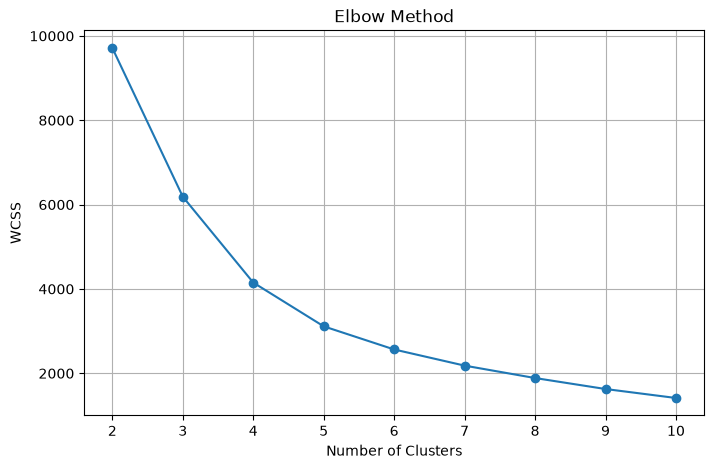

In [7]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

### Silhouette Score

In [8]:
for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"k = {k}  |  Silhouette Score = {score:.3f}")

k = 2  |  Silhouette Score = 0.480
k = 3  |  Silhouette Score = 0.451
k = 4  |  Silhouette Score = 0.472
k = 5  |  Silhouette Score = 0.444
k = 6  |  Silhouette Score = 0.437
k = 7  |  Silhouette Score = 0.431
k = 8  |  Silhouette Score = 0.434
k = 9  |  Silhouette Score = 0.433
k = 10  |  Silhouette Score = 0.436


- The Elbow Method clearly points to 4.
- The Silhouette Score (0.472) is still strong.
- Four customer groups are much more useful for marketing and retention strategies.
- It creates richer business insights for your internship project and final presentation.

- We will use 4 clusters 

### Train Final K-Means Model

In [9]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

clusters[:10]

array([2, 0, 2, 0, 3, 3, 3, 2, 3, 0], dtype=int32)

### Add cluster Label

In [10]:
df["Cluster"] = clusters

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Cluster
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,2
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,2
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,3


### Number of segment per cluster

In [11]:
df["Cluster"].value_counts().sort_index()

Cluster
0    1159
1    1904
2    1704
3    2276
Name: count, dtype: int64

### cluster distribution

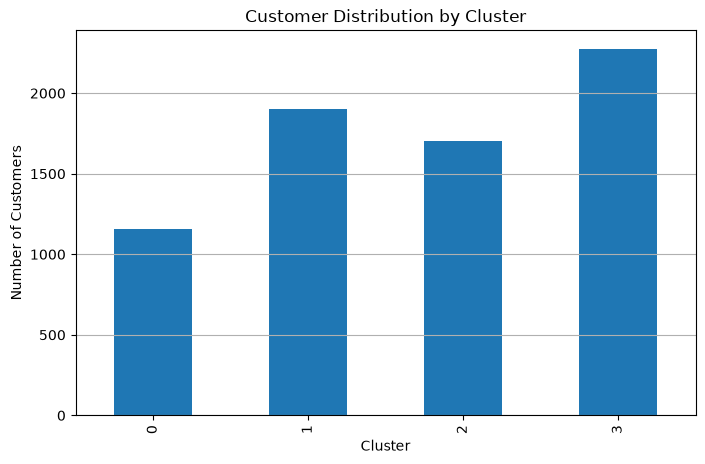

In [12]:
plt.figure(figsize=(8,5))

df["Cluster"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Customer Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.grid(axis="y")

plt.show()

### PCA for visualization

In [13]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(7043, 2)


### scatter plot of cluster

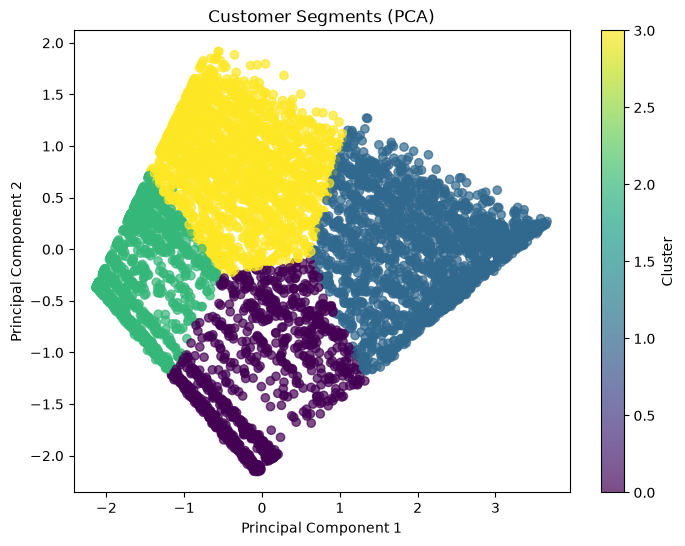

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    alpha=0.7
)

plt.title("Customer Segments (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

### Cluster profile

In [17]:
cluster_summary = df.groupby("Cluster")[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]].mean().round(2)

cluster_summary

,tenure,MonthlyCharges,TotalCharges
Cluster,,,
0,53.59,34.92,1836.58
1,59.53,93.31,5548.65
2,10.23,31.77,308.96
3,15.42,80.78,1253.01


### Save segmentation Modlel

In [18]:
import os
import joblib

os.makedirs("../models/segmentation", exist_ok=True)

joblib.dump(kmeans, "../models/segmentation/kmeans_model.pkl")

joblib.dump(scaler, "../models/segmentation/scaler.pkl")

print("✅ Segmentation model saved successfully!")

✅ Segmentation model saved successfully!


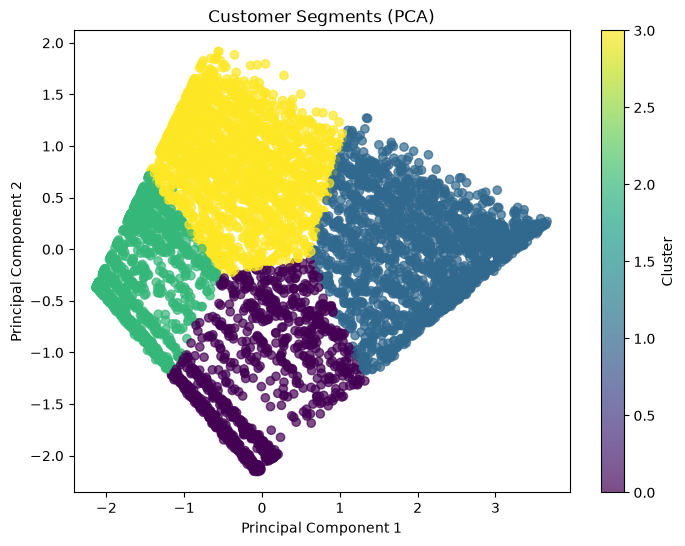

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    alpha=0.7
)

plt.title("Customer Segments (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [20]:
cluster_summary = df.groupby("Cluster")[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]].mean().round(2)

cluster_summary

,tenure,MonthlyCharges,TotalCharges
Cluster,,,
0,53.59,34.92,1836.58
1,59.53,93.31,5548.65
2,10.23,31.77,308.96
3,15.42,80.78,1253.01


# Business Interpretation of Customer Segments

### Cluster 0 – Loyal Budget Customers
- Long tenure
- Low monthly charges
- Stable customers
- Suitable for cross-selling

---

### Cluster 1 – Premium Loyal Customers
- Highest revenue customers
- Long-term subscribers
- Highest retention priority
- Offer loyalty rewards and VIP services

---

### Cluster 2 – New Budget Customers
- Recently joined
- Low spending
- Focus on onboarding and engagement

---

### Cluster 3 – New Premium Customers
- Recently joined
- High monthly charges
- Higher churn risk
- Offer personalized retention strategies